## Conditional Covariance Function

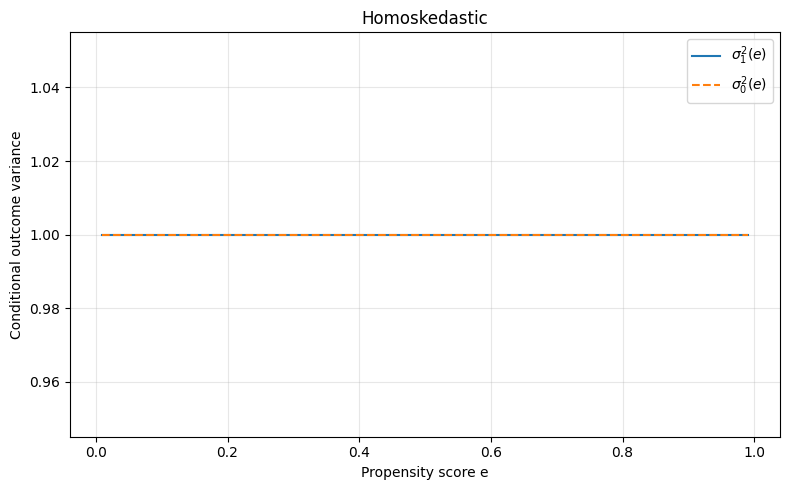

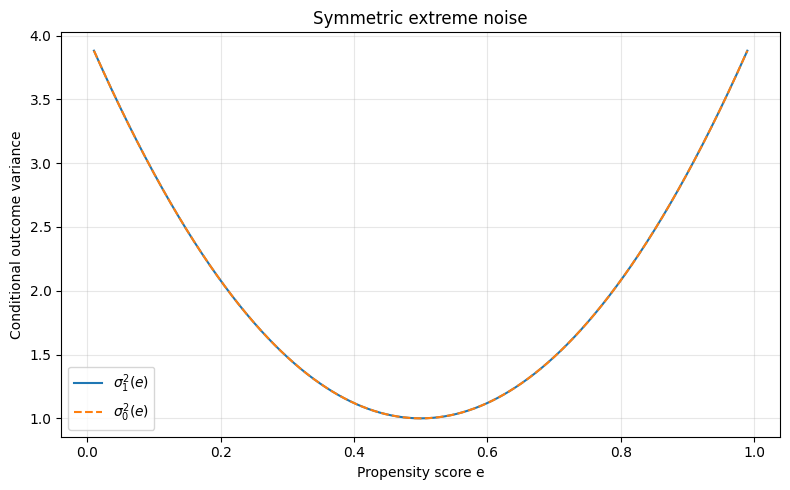

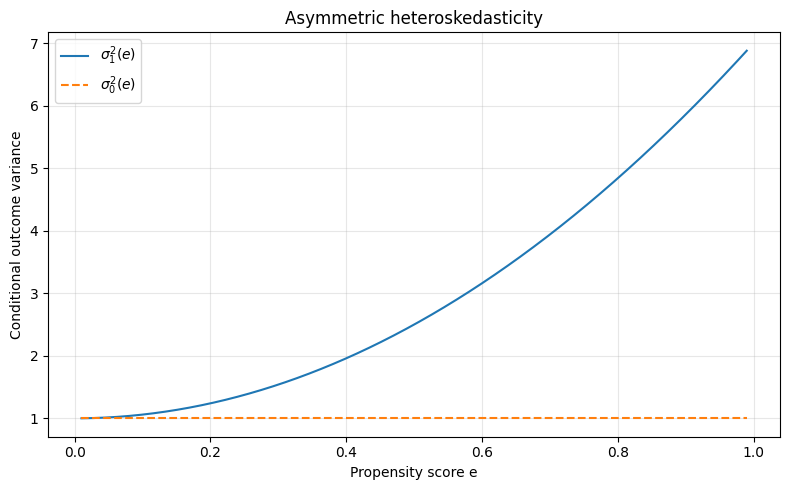

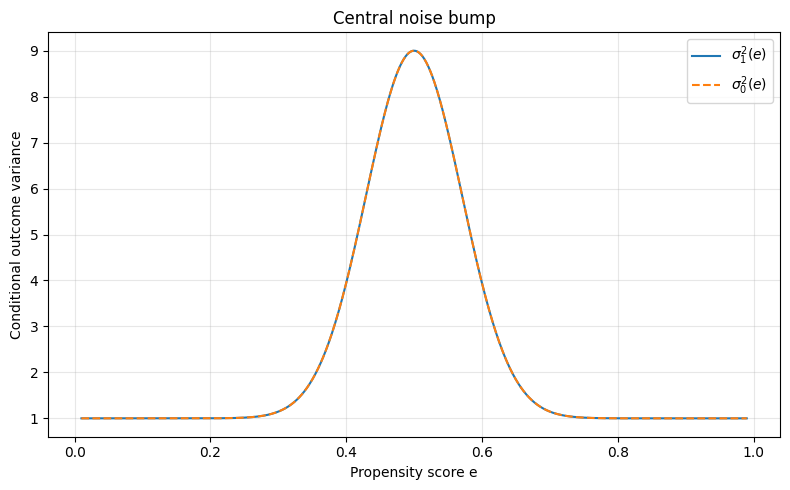

In [1]:
import numpy as np
import matplotlib.pyplot as plt

e = np.linspace(0.01, 0.99, 1000)

scenarios = {
    "Homoskedastic": (
        np.ones_like(e),
        np.ones_like(e)
    ),

    "Symmetric extreme noise": (
        1 + 12 * (e - 0.5)**2,
        1 + 12 * (e - 0.5)**2
    ),

    "Asymmetric heteroskedasticity": (
        1 + 6 * e**2,
        np.ones_like(e)
    ),

    "Central noise bump": (
        1 + 8 * np.exp(-((e - 0.5) / 0.10)**2),
        1 + 8 * np.exp(-((e - 0.5) / 0.10)**2)
    )
}

for name, (sigma1, sigma0) in scenarios.items():
    plt.figure(figsize=(8, 5))

    plt.plot(e, sigma1, label=r"$\sigma_1^2(e)$")
    plt.plot(e, sigma0, linestyle="--", label=r"$\sigma_0^2(e)$")

    plt.xlabel("Propensity score e")
    plt.ylabel("Conditional outcome variance")
    plt.title(name)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

This figure shows the conditional outcome variance structures imposed in each simulation scenario.

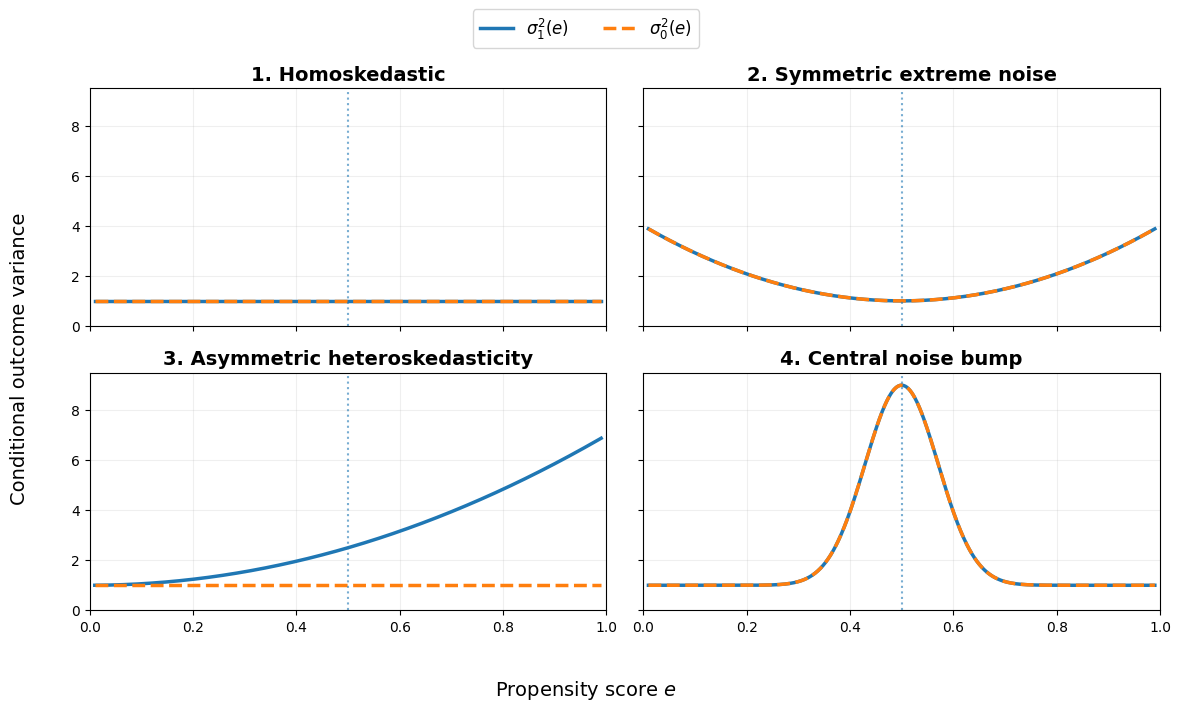

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Propensity-score grid
e = np.linspace(0.01, 0.99, 1000)

# Same variance scenarios used in 03_extension_heteroskedasticity.py
scenarios = {
    "1. Homoskedastic": (
        np.ones_like(e),
        np.ones_like(e)
    ),

    "2. Symmetric extreme noise": (
        1 + 12 * (e - 0.5)**2,
        1 + 12 * (e - 0.5)**2
    ),

    "3. Asymmetric heteroskedasticity": (
        1 + 6 * e**2,
        np.ones_like(e)
    ),

    "4. Central noise bump": (
        1 + 8 * np.exp(-((e - 0.5) / 0.10)**2),
        1 + 8 * np.exp(-((e - 0.5) / 0.10)**2)
    )
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 7),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (name, (sigma1, sigma0)) in zip(axes, scenarios.items()):

    ax.plot(
        e, sigma1,
        linewidth=2.5,
        label=r"$\sigma_1^2(e)$"
    )

    ax.plot(
        e, sigma0,
        linewidth=2.5,
        linestyle="--",
        label=r"$\sigma_0^2(e)$"
    )

    # Reference: best overlap occurs around e = 0.5
    ax.axvline(
        0.5,
        linestyle=":",
        linewidth=1.5,
        alpha=0.6
    )

    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 9.5)

    ax.grid(alpha=0.2)

# Shared labels
fig.supxlabel("Propensity score $e$", fontsize=14)
fig.supylabel("Conditional outcome variance", fontsize=14)

# One common legend instead of repeating it 4 times
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01),
    fontsize=12
)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.94])

# Optional: save high-resolution version for Google Slides
plt.savefig(
    "four_variance_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()